In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from pathlib import Path
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error # (Methods used come from validation in prnet trainer)
from models.simple_baselines import control_baseline, mean_baseline_fold, mean_baseline, technical_duplicate_fold, technical_duplicate_baseline, td_split

#### Load Expression Data

In [2]:
expression_data_dir = Path("/Users/ani/Thesis/prnet_eval/results/batch_run_07/intermediate_results/preprocessed_dataset.h5ad")
adata = sc.read_h5ad(expression_data_dir)


In [3]:
adata

AnnData object with n_obs × n_vars = 691217 × 978
    obs: 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_type', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'Drug', 'cov_drug_name', 'cov_drug_dose_name', 'control', 'paired_control_index', 'canonical_smiles', 'fingerprint_smiles', 'canonical_smiles_split_0', 'canonical_smiles_split_1', 'canonical_smiles_split_2', 'canonical_smiles_split_3', 'canonical_smiles_split_4', 'fingerprint_smiles_split_0', 'fingerprint_smiles_split_1', 'fingerprint_smiles_split_2', 'fingerprint_smiles_split_3', 'fingerprint_smiles_split_4'
    var: 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space'

#### Simple Baselines

##### 1. Control Baseline

In [4]:
ctl_expression_profile = control_baseline(adata=adata, split_axis='canonical_smiles')
ctl_expression_profile

,10007,1001,10013,10038,10046,10049,10051,10057,10058,10059,...,9918,9924,9926,9928,993,994,9943,9961,998,9988
canonical_smiles fold,,,,,,,,,,,,,,,,,,,,,
0,9.74721,6.405429,8.140743,8.893025,4.840526,10.589222,9.79988,5.483813,8.077561,10.18826,...,9.214887,5.890706,8.997166,7.195313,8.566171,10.767612,8.13315,9.315574,10.986598,7.661261
1,9.74721,6.405429,8.140743,8.893025,4.840526,10.589222,9.79988,5.483813,8.077561,10.18826,...,9.214887,5.890706,8.997166,7.195313,8.566171,10.767612,8.13315,9.315574,10.986598,7.661261
2,9.74721,6.405429,8.140743,8.893025,4.840526,10.589222,9.79988,5.483813,8.077561,10.18826,...,9.214887,5.890706,8.997166,7.195313,8.566171,10.767612,8.13315,9.315574,10.986598,7.661261
3,9.74721,6.405429,8.140743,8.893025,4.840526,10.589222,9.79988,5.483813,8.077561,10.18826,...,9.214887,5.890706,8.997166,7.195313,8.566171,10.767612,8.13315,9.315574,10.986598,7.661261
4,9.74721,6.405429,8.140743,8.893025,4.840526,10.589222,9.79988,5.483813,8.077561,10.18826,...,9.214887,5.890706,8.997166,7.195313,8.566171,10.767612,8.13315,9.315574,10.986598,7.661261


##### Mean Baseline

In [5]:
fold_0_train = adata[adata.obs['canonical_smiles_split_0'] == 'train']
specification1 = 'cell_type'
specification2 = 'cov_drug_dose_name'

In [6]:
mean_expression_profile = mean_baseline(adata_train=adata, specification='cell_type', split_axis='canonical_smiles')
mean_expression_profile

aggregation finished
Mean baseline for fold done.
in fold: cell_type
22RV1      canonical_smiles_split_0
A204       canonical_smiles_split_0
A375       canonical_smiles_split_0
A549       canonical_smiles_split_0
AGS        canonical_smiles_split_0
                     ...           
XC.P935    canonical_smiles_split_0
XC.P936    canonical_smiles_split_0
XC.R10     canonical_smiles_split_0
YAPC       canonical_smiles_split_0
ZR751      canonical_smiles_split_0
Name: fold name, Length: 131, dtype: object
aggregation finished
Mean baseline for fold done.
in fold: cell_type
22RV1      canonical_smiles_split_1
5637       canonical_smiles_split_1
A204       canonical_smiles_split_1
A375       canonical_smiles_split_1
A549       canonical_smiles_split_1
                     ...           
XC.P935    canonical_smiles_split_1
XC.P936    canonical_smiles_split_1
XC.R10     canonical_smiles_split_1
YAPC       canonical_smiles_split_1
ZR751      canonical_smiles_split_1
Name: fold name, Length: 1

,10007,1001,10013,10038,10046,10049,10051,10057,10058,10059,...,9924,9926,9928,993,994,9943,9961,998,9988,fold name
cell_type,,,,,,,,,,,,,,,,,,,,,
22RV1,10.116197,6.876052,7.920986,8.818736,4.721243,11.788380,9.924510,5.313807,7.263280,9.845051,...,4.962477,8.491772,8.221327,8.576868,10.140806,8.198073,8.067706,10.067877,7.983999,canonical_smiles_split_0
A204,9.984566,6.177871,7.994066,7.961029,4.123738,12.798295,11.420054,6.440717,7.105200,11.489321,...,6.006221,8.292304,11.767233,8.934541,7.460621,10.046204,5.696671,8.605608,10.418158,canonical_smiles_split_0
A375,9.766097,6.277514,7.589051,8.579869,4.667933,11.022317,9.707924,5.372165,8.600187,10.275773,...,5.525781,8.730689,6.848218,9.213173,11.613369,7.825045,8.029189,10.788133,7.525310,canonical_smiles_split_0
A549,9.721839,6.480954,7.904228,8.789926,4.848603,10.630509,9.555355,5.079279,7.608132,9.863284,...,5.496373,9.294927,7.560652,8.715211,11.493400,7.808324,9.076164,11.062115,7.407031,canonical_smiles_split_0
AGS,8.464850,7.199740,8.527655,9.245515,4.502485,11.820030,10.143070,5.392180,6.388370,11.148285,...,8.887870,8.132965,7.965005,9.342220,10.073460,8.207435,8.581065,11.609620,9.454615,canonical_smiles_split_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WI38,9.635238,5.226600,7.302000,8.599483,4.128221,9.804575,11.009925,6.470800,10.428975,10.177571,...,6.257188,8.707938,7.155104,9.896254,12.208992,7.748650,6.745412,10.721325,7.763021,canonical_smiles_split_4
XC.L10,9.916849,6.211781,8.270788,8.570622,4.811679,10.793238,9.267355,5.523034,8.556394,10.054135,...,5.565963,8.943020,6.721685,7.581099,11.277277,7.997769,9.657427,10.977630,7.242778,canonical_smiles_split_4
XC.L100,10.439349,5.364696,9.119487,9.169606,3.983433,11.100792,9.563845,4.237904,8.693165,10.795461,...,5.198511,10.880627,7.244691,8.626215,13.112600,7.616203,12.114092,10.418354,7.901266,canonical_smiles_split_4


In [7]:
mean_expression_profile[mean_expression_profile.index == '1HAE']

,10007,1001,10013,10038,10046,10049,10051,10057,10058,10059,...,9924,9926,9928,993,994,9943,9961,998,9988,fold name
cell_type,,,,,,,,,,,,,,,,,,,,,
1HAE,10.127408,5.601508,8.117367,8.478613,3.983529,9.428288,10.913104,6.243737,10.640375,10.181204,...,6.264754,8.722525,6.8109,10.113579,11.5884,7.802413,6.237371,11.836233,7.367312,canonical_smiles_split_2
1HAE,10.127408,5.601508,8.117367,8.478613,3.983529,9.428288,10.913104,6.243737,10.640375,10.181204,...,6.264754,8.722525,6.8109,10.113579,11.5884,7.802413,6.237371,11.836233,7.367312,canonical_smiles_split_3
1HAE,10.127408,5.601508,8.117367,8.478613,3.983529,9.428288,10.913104,6.243737,10.640375,10.181204,...,6.264754,8.722525,6.8109,10.113579,11.5884,7.802413,6.237371,11.836233,7.367312,canonical_smiles_split_4


In [8]:
index_counts = mean_expression_profile.index.value_counts()

rare_indices = index_counts[index_counts < 5].index

rare_metadata_df = mean_expression_profile[mean_expression_profile.index.isin(rare_indices)].copy()
rare_metadata_df

,10007,1001,10013,10038,10046,10049,10051,10057,10058,10059,...,9924,9926,9928,993,994,9943,9961,998,9988,fold name
cell_type,,,,,,,,,,,,,,,,,,,,,
A204,9.984566,6.177871,7.994066,7.961029,4.123738,12.798295,11.420054,6.440717,7.105200,11.489321,...,6.006221,8.292304,11.767233,8.934541,7.460621,10.046204,5.696671,8.605608,10.418158,canonical_smiles_split_0
AGS,8.464850,7.199740,8.527655,9.245515,4.502485,11.820030,10.143070,5.392180,6.388370,11.148285,...,8.887870,8.132965,7.965005,9.342220,10.073460,8.207435,8.581065,11.609620,9.454615,canonical_smiles_split_0
BC3C,8.778185,7.678585,8.244755,9.471885,4.403530,11.518700,10.287480,5.250475,6.462795,11.208670,...,8.472430,8.276230,8.022255,9.669650,9.718120,8.533910,8.094295,11.724500,9.201330,canonical_smiles_split_0
BEN,8.476325,6.943845,9.145930,8.810475,4.314635,11.831830,9.843760,5.335425,6.088105,10.869265,...,9.278995,8.017640,6.887120,9.035610,9.894380,7.990470,9.011570,11.733660,9.956730,canonical_smiles_split_0
BICR6,8.896254,7.895188,8.280650,9.678050,4.320204,11.655692,10.232738,5.074838,6.411850,11.222450,...,8.469767,8.478333,7.485933,9.524700,9.861950,8.488629,8.345646,11.696437,8.680338,canonical_smiles_split_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P1A82,9.882136,5.369918,8.222755,8.552231,4.026801,9.846943,11.022679,6.359717,10.462838,9.953999,...,6.194657,8.657504,6.685810,9.821597,11.697285,8.107508,6.204228,10.606918,7.268021,canonical_smiles_split_4
SKNSH,9.222563,4.748923,6.751316,8.293146,4.451353,11.887052,8.536128,7.340597,9.345512,11.640808,...,4.228841,10.294829,4.714666,9.482484,13.015978,9.908890,10.931514,9.794900,7.454599,canonical_smiles_split_4
SNU1040,10.285471,5.199573,8.919852,8.586058,5.281556,11.454594,8.992225,4.089696,9.178617,11.635773,...,5.609417,12.033156,8.190444,7.859229,13.936248,7.807415,13.140400,9.917667,7.269063,canonical_smiles_split_4


##### Technical Duplicate

In [9]:
"""
# CHECK CELL TYPE DISTRIBUTION AMONG BOTH SPLITS
counts = pd.crosstab(
    td_split_df.obs["cell_type"],
    td_split_df.obs["ground_truth"].map({True: "Ground Truth", False: "Tech Duplicate"})
)

# 2. Calculate percentage distribution within each split (column-wise normalized)
percentages = (counts.div(counts.sum(axis=0), axis=1) * 100).round(2)

# 3. Combine into a clean summary table
summary = pd.concat([counts, percentages], axis=1, keys=["Counts", "Proportions (%)"])
summary
"""

'\n# CHECK CELL TYPE DISTRIBUTION AMONG BOTH SPLITS\ncounts = pd.crosstab(\n    td_split_df.obs["cell_type"],\n    td_split_df.obs["ground_truth"].map({True: "Ground Truth", False: "Tech Duplicate"})\n)\n\n# 2. Calculate percentage distribution within each split (column-wise normalized)\npercentages = (counts.div(counts.sum(axis=0), axis=1) * 100).round(2)\n\n# 3. Combine into a clean summary table\nsummary = pd.concat([counts, percentages], axis=1, keys=["Counts", "Proportions (%)"])\nsummary\n'

In [10]:
"""
# Filter for rows where either Ground Truth or Tech Duplicate has a count of 0
zero_count_rows = summary[
    (summary[("Counts", "Ground Truth")] == 0) | 
    (summary[("Counts", "Tech Duplicate")] == 0)
]

# Get the total count of missing cell types
missing_cell_type_count = len(zero_count_rows)

print(f"Number of cell types missing from at least one split: {missing_cell_type_count}")
zero_count_rows
"""

'\n# Filter for rows where either Ground Truth or Tech Duplicate has a count of 0\nzero_count_rows = summary[\n    (summary[("Counts", "Ground Truth")] == 0) | \n    (summary[("Counts", "Tech Duplicate")] == 0)\n]\n\n# Get the total count of missing cell types\nmissing_cell_type_count = len(zero_count_rows)\n\nprint(f"Number of cell types missing from at least one split: {missing_cell_type_count}")\nzero_count_rows\n'

In [11]:
# Count how many unique SMILES (compounds) exist per cell type
adata_compounds = adata[adata.obs['control'] == 0]
compounds_per_celltype = (
    adata_compounds.obs.groupby("cell_type")['canonical_smiles']
    .nunique()
)

# Cell types with only 1 compound CANNOT be split under strict compound grouping
unstratifiable = compounds_per_celltype[compounds_per_celltype == 1]

print(f"Total unstratifiable cell types: {len(unstratifiable)}")
print(unstratifiable)

Total unstratifiable cell types: 26
cell_type
1HAE        1
5637        1
AN3CA       1
BC3C        1
CAL29       1
CW2         1
DV90        1
HCC827      1
HEC151      1
HFL1        1
IM95        1
IMR90       1
J82         1
LN229       1
MFE319      1
NCIH1563    1
NCIH1781    1
OC314       1
OVCAR8      1
OVTOKO      1
P1A82       1
SKNSH       1
SNU1040     1
VMCUB1      1
WI38        1
XC.P092     1
Name: canonical_smiles, dtype: int64


/var/folders/m2/_fdyhpc976zdfvy7gkp447jw0000gn/T/ipykernel_37592/3227914250.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_compounds.obs.groupby("cell_type")['canonical_smiles']


In [12]:
# Total sum of cells across all unstratifiable cell types
total_unstratifiable_cells = adata_compounds.obs['cell_type'].isin(unstratifiable.index).sum()

print(total_unstratifiable_cells)

439


In [13]:
# For the td splitting, two things are important:
# - same smiles string appears only in one split (no data leakage)
# - the cell_type values should be as evenly distributed as possible among the splits so as to be able to evaluate with the technical duplicate split on as many cell_types as possible

# Problem: For some cell types, they are not distributable among both splits without causing data leakage, because they are only associated with one smiles string.
# Workaround: These cell types are assigned to the ground truth. The model will see more data during the test like this.
#              During Evaluation, these cells will have to be excluded, because they do not have an equivalent counterpart for evaluation in the technical duplicate set.
# Analysis above shows this will be the case for 26 cell types in total, which makes for 439 rows affected in total.

In [14]:
technical_duplicate = technical_duplicate_baseline(adata=adata, split_type='test', split_axis='canonical_smiles')
technical_duplicate


[INFO] No singletons found in this fold.

[INFO] No singletons found in this fold.

[INFO] No singletons found in this fold.

[INFO] No singletons found in this fold.

[INFO] No singletons found in this fold.


,cell_type,pert_id,ground_truth,technical_duplicate,10007,1001,10013,10038,10046,10049,...,9924,9926,9928,993,994,9943,9961,998,9988,fold name
0,A549,BRD-A00420644,1,0,9.182287,6.137949,6.990408,8.345924,4.829043,10.317229,...,5.883453,7.785196,6.594854,8.130373,11.155586,7.061941,7.050187,11.085214,7.336895,canonical_smiles_split_0
1,A549,BRD-A00420644,0,1,9.144173,6.032620,7.193192,8.229569,5.212875,10.781532,...,5.347260,8.035567,6.701740,8.554435,10.430677,7.171817,6.768442,11.329266,7.448050,canonical_smiles_split_0
2,HA1E,BRD-A01295252,1,0,9.620639,6.168608,7.116401,9.057848,4.479726,10.929234,...,5.509307,8.069750,7.567425,8.623476,10.847736,8.139339,7.570578,10.630275,8.168213,canonical_smiles_split_0
3,HA1E,BRD-A01295252,0,1,9.988194,5.962541,7.114652,8.918441,4.639053,11.076427,...,5.657258,7.912809,7.007175,8.217154,10.737685,8.031000,7.662936,10.444834,8.318305,canonical_smiles_split_0
4,A375,BRD-A01320529,1,0,9.390542,6.339154,8.193944,8.664495,4.575564,10.554612,...,6.225252,8.908474,7.445941,9.013876,10.319798,7.893541,8.577373,10.965176,7.608340,canonical_smiles_split_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,MCF7,BRD-M98649031,0,1,11.478251,5.302300,9.017651,9.138850,3.655775,8.371050,...,5.635800,10.889250,7.747050,9.259701,13.477500,8.635250,12.807650,9.454150,8.274200,canonical_smiles_split_4
2344,HME1,BRD-U22633929,1,0,9.148265,7.577170,7.942403,9.066413,4.576857,11.344068,...,5.614477,8.716310,6.860610,8.053551,12.011307,7.368268,8.288391,11.418231,7.208909,canonical_smiles_split_4
2345,HME1,BRD-U22633929,0,1,9.074301,7.503581,8.213171,9.155993,4.322937,11.278900,...,5.340213,8.859719,7.110966,8.209017,11.544557,7.629490,8.186990,11.316770,7.375957,canonical_smiles_split_4
2346,A549,BRD-U24835547,1,0,10.577308,8.325966,8.855419,9.442999,4.585833,11.061187,...,6.489489,9.804944,7.761525,9.435969,11.716771,8.659987,10.827862,11.820492,7.595205,canonical_smiles_split_4


In [15]:
technical_duplicate[technical_duplicate["technical_duplicate"] == 1]

,cell_type,pert_id,ground_truth,technical_duplicate,10007,1001,10013,10038,10046,10049,...,9924,9926,9928,993,994,9943,9961,998,9988,fold name
1,A549,BRD-A00420644,0,1,9.144173,6.032620,7.193192,8.229569,5.212875,10.781532,...,5.347260,8.035567,6.701740,8.554435,10.430677,7.171817,6.768442,11.329266,7.448050,canonical_smiles_split_0
3,HA1E,BRD-A01295252,0,1,9.988194,5.962541,7.114652,8.918441,4.639053,11.076427,...,5.657258,7.912809,7.007175,8.217154,10.737685,8.031000,7.662936,10.444834,8.318305,canonical_smiles_split_0
5,A549,BRD-A01320529,0,1,9.310951,6.377855,8.442225,8.711362,4.899979,10.654902,...,6.351665,8.865085,7.307600,9.158163,9.956028,7.680418,8.974010,10.997982,7.719229,canonical_smiles_split_0
7,VCAP,BRD-A02836799,0,1,8.054501,7.740017,6.341884,7.636950,4.947550,10.981833,...,5.572866,6.400283,8.042168,7.467000,12.230834,7.709267,6.441317,10.527917,7.542984,canonical_smiles_split_0
9,A375,BRD-A02904414,0,1,9.039616,5.758269,8.321754,8.672947,4.217319,10.647678,...,6.188531,8.859034,7.110494,10.504377,11.210043,7.843112,7.395306,10.614750,8.333497,canonical_smiles_split_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,A375,BRD-M98279124,0,1,9.493876,5.317225,7.135000,8.577613,4.603713,9.820625,...,6.509612,8.242625,7.030350,8.943775,12.059150,8.110575,6.294850,11.621500,8.245200,canonical_smiles_split_4
2341,MCF7,BRD-M98379218,0,1,9.787500,5.403250,7.701500,8.990299,4.467700,10.079100,...,6.650700,7.726250,7.474700,8.094500,12.029900,8.158051,7.059200,11.197700,8.717100,canonical_smiles_split_4
2343,MCF7,BRD-M98649031,0,1,11.478251,5.302300,9.017651,9.138850,3.655775,8.371050,...,5.635800,10.889250,7.747050,9.259701,13.477500,8.635250,12.807650,9.454150,8.274200,canonical_smiles_split_4
2345,HME1,BRD-U22633929,0,1,9.074301,7.503581,8.213171,9.155993,4.322937,11.278900,...,5.340213,8.859719,7.110966,8.209017,11.544557,7.629490,8.186990,11.316770,7.375957,canonical_smiles_split_4


#### Simple Metrics

##### 1. Control Baseline

In [32]:
all_fold_metrics = []

for fold_num in range(5):
    data = adata.obs[f'canonical_smiles_split_{fold_num}'] == 'valid'
    fold_obs = adata.obs[data]
    fold_X = adata[data, :].X.toarray()
        
    predicted_control_profile = ctl_expression_profile.loc[fold_num].to_numpy()

    for index, sample_id in enumerate(fold_obs.index):
        sample_expression_profile = fold_X[index]

        r2_ctl = pearsonr(x=sample_expression_profile, y=predicted_control_profile).correlation
        pearson_delta_ctl = 0.0 if (predicted_control_profile == predicted_control_profile).all() else pearsonr(x=sample_expression_profile-predicted_control_profile, y=predicted_control_profile-predicted_control_profile).correlation
        mse_ctl = mean_squared_error(y_true=sample_expression_profile, y_pred=predicted_control_profile)

        all_fold_metrics.append(
            {
                "fold": fold_num,
                "sample_id": sample_id,
                "Pearson": r2_ctl,
                "Pearson Delta": pearson_delta_ctl,
                "MSE": mse_ctl,
            }
        )

control_metrics = pd.DataFrame(all_fold_metrics)
control_metrics

,fold,sample_id,Pearson,Pearson Delta,MSE
0,0,ABY001_A375_XH_X1_B15:A15,0.831991,0.0,1.551834
1,0,ABY001_A375_XH_X1_B15:A19,0.843556,0.0,1.403567
2,0,ABY001_A375_XH_X1_B15:A23,0.828009,0.0,1.504467
3,0,ABY001_A375_XH_X1_B15:B15,0.831264,0.0,1.623267
4,0,ABY001_A375_XH_X1_B15:B19,0.831757,0.0,1.698233
...,...,...,...,...,...
502354,4,REP.B028_YAPC_24H_X2_B23:O02,0.811880,0.0,3.187637
502355,4,REP.B028_YAPC_24H_X2_B23:O03,0.822203,0.0,2.533782
502356,4,REP.B028_YAPC_24H_X2_B23:O04,0.821349,0.0,2.559575
502357,4,REP.B028_YAPC_24H_X2_B23:O05,0.830849,0.0,2.598396


##### 2. Mean Baseline

In [33]:
# Quicker option (about 6 min)
all_fold_metrics = []

for fold_num in range(5):
    split_name = f"canonical_smiles_split_{fold_num}"
    mask = adata.obs[split_name] == 'train'
    fold_obs = adata.obs[mask]

    mean_baseline_fold = mean_expression_profile[mean_expression_profile["fold name"] == split_name].drop(columns=["fold name"])
    control_profile = ctl_expression_profile.loc[fold_num].to_numpy()

    fold_X = adata[mask, :].X.toarray()

    sample_ids = fold_obs.index
    cell_types = fold_obs["cell_type"].values

    for index, sample_id in enumerate(sample_ids):
        sample_cell_type = cell_types[index]
        sample_expression_profile = fold_X[index]

        predicted_mean_profile = mean_baseline_fold.loc[sample_cell_type].to_numpy()

        mse_mean = mean_squared_error(sample_expression_profile, predicted_mean_profile)
        r2_mean = pearsonr(x=sample_expression_profile, y=predicted_mean_profile).correlation
        pearson_delta_mean = 0.0 if (predicted_mean_profile == control_profile).all() else pearsonr(x=sample_expression_profile-control_profile, y=predicted_mean_profile-control_profile).correlation

        all_fold_metrics.append(
            {
                "fold": fold_num,
                "sample_id": sample_id,
                "cell_type": sample_cell_type,
                "Pearson": r2_mean,
                "Pearson Delta": pearson_delta_mean,
                "MSE": mse_mean,
            }
        )

mean_bl_metrics = pd.DataFrame(all_fold_metrics)
mean_bl_metrics

,fold,sample_id,cell_type,Pearson,Pearson Delta,MSE
0,0,ABY001_A375_XH_X1_B15:A14,A375,0.777104,-0.106777,2.105113
1,0,ABY001_A375_XH_X1_B15:A18,A375,0.765748,-0.065001,2.524885
2,0,ABY001_A375_XH_X1_B15:A22,A375,0.773378,-0.090830,2.322767
3,0,ABY001_A375_XH_X1_B15:B14,A375,0.784129,-0.111360,2.118757
4,0,ABY001_A375_XH_X1_B15:B18,A375,0.783575,-0.078042,2.332767
...,...,...,...,...,...,...
1511164,4,TSAI001_SAD21NPC2_XH_X1_B16:C02,NPC,0.823136,0.347660,2.914641
1511165,4,TSAI001_SAD21NPC2_XH_X1_B16:D02,NPC,0.817480,0.376514,2.992547
1511166,4,TSAI001_SB1NPC3_XH_X1_B16:N02,NPC,0.823979,0.388202,2.907671
1511167,4,TSAI001_SB1NPC3_XH_X1_B16:O02,NPC,0.796692,0.351397,3.495139


##### 3. Technical Duplicate

In [34]:
all_fold_metrics = []

for fold_num in range(5):
    split_name = f"canonical_smiles_split_{fold_num}"
    
    mask = adata.obs[split_name] == 'test'
    fold_obs = adata.obs[mask]
    if len(fold_obs) == 0:
        continue

    control_profile = ctl_expression_profile.loc[fold_num].to_numpy()

    # 3. Build technical duplicate & ground truth lookups for this fold
    td_lookup = (
        technical_duplicate[(technical_duplicate["fold name"] == split_name) & (technical_duplicate["technical_duplicate"] == 1)]
        .set_index("pert_id")
        .drop(columns=["technical_duplicate", "ground_truth", "fold name", "cell_type"])
    )

    gt_lookup = (
        technical_duplicate[(technical_duplicate["fold name"] == split_name) & (technical_duplicate["ground_truth"] == 1)]
        .set_index("pert_id")
        .drop(columns=["technical_duplicate", "ground_truth", "fold name", "cell_type"])
    )

    valid_perts = set(td_lookup.index).intersection(gt_lookup.index)

    # 4. Extract arrays once per fold (fast NumPy indexing)
    sample_ids = fold_obs.index
    pert_ids = fold_obs["pert_id"].values

    for index, sample_id in enumerate(sample_ids):
        sample_pert = pert_ids[index]

        if sample_pert in valid_perts:
            td_profile = td_lookup.loc[sample_pert].to_numpy().flatten()
            gt_profile = gt_lookup.loc[sample_pert].to_numpy().flatten()

            mse_td = mean_squared_error(gt_profile, td_profile)
            r2_td = pearsonr(x=gt_profile, y=td_profile).correlation
            pearson_delta_td = 0.0 if (td_profile == control_profile).all() else pearsonr(x=gt_profile - control_profile, y=td_profile - control_profile).correlation
        else:
            r2_td = np.nan
            pearson_delta_td = np.nan
            mse_td = np.nan

        all_fold_metrics.append(
            {
                "fold": fold_num,
                "sample_id": sample_id,
                "pert_id": sample_pert,
                "Pearson": r2_td,
                "Pearson Delta": pearson_delta_td,
                "MSE": mse_td,
            }
        )

td_metrics = pd.DataFrame(all_fold_metrics)
td_metrics

,fold,sample_id,pert_id,Pearson,Pearson Delta,MSE
0,0,ABY001_A375_XH_X1_B15:D14,BRD-K70511574,0.997903,0.935684,0.015863
1,0,ABY001_A375_XH_X1_B15:D18,BRD-K70511574,0.997903,0.935684,0.015863
2,0,ABY001_A375_XH_X1_B15:D22,BRD-K70511574,0.997903,0.935684,0.015863
3,0,ABY001_A375_XH_X1_B15:E14,BRD-K70511574,0.997903,0.935684,0.015863
4,0,ABY001_A375_XH_X1_B15:E18,BRD-K70511574,0.997903,0.935684,0.015863
...,...,...,...,...,...,...
503377,4,REP.B005_HELA_3H_X3_B22:P23,BRD-K11717138,0.996701,0.950397,0.027683
503378,4,REP.B005_HELA_3H_X3_B22:P24,BRD-K11717138,0.996701,0.950397,0.027683
503379,4,TAA001_SHSY5Y_24H_X1_B33:B13,BRD-K77908580,0.998786,0.969725,0.009009
503380,4,TAA001_SHSY5Y_24H_X2_B33:B13,BRD-K77908580,0.998786,0.969725,0.009009


In [19]:
td_metrics[td_metrics.isna().any(axis=1)]

,fold,sample_id,pert_id,r2,pearson_delta,mse


##### 4. PRnet

In [20]:
smiles_split_metrics_path = Path("/Users/ani/Thesis/prnet_eval/results/batch_run_07/training_smiles_splits")
#fp_split_metrics_path = Path("/Users/ani/Thesis/prnet_eval/results/batch_run_07")

In [21]:
smiles_metrics_fold_0_path = Path(smiles_split_metrics_path/ "canonical_smiles_split_0metrics_comb.csv")
smiles_metrics_fold_1_path = Path(smiles_split_metrics_path/ "canonical_smiles_split_1metrics_comb.csv")
smiles_metrics_fold_2_path = Path(smiles_split_metrics_path/ "canonical_smiles_split_2metrics_comb.csv")
smiles_metrics_fold_3_path = Path(smiles_split_metrics_path/ "canonical_smiles_split_3metrics_comb.csv")
smiles_metrics_fold_4_path = Path(smiles_split_metrics_path/ "canonical_smiles_split_4metrics_comb.csv")

In [22]:
"""
fp_metrics_fold_0_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_0metrics_comb.csv")
fp_metrics_fold_1_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_1metrics_comb.csv")
fp_metrics_fold_2_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_2metrics_comb.csv")
fp_metrics_fold_3_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_3metrics_comb.csv")
fp_metrics_fold_4_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_4metrics_comb.csv")
"""

'\nfp_metrics_fold_0_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_0metrics_comb.csv")\nfp_metrics_fold_1_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_1metrics_comb.csv")\nfp_metrics_fold_2_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_2metrics_comb.csv")\nfp_metrics_fold_3_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_3metrics_comb.csv")\nfp_metrics_fold_4_path = Path(fp_split_metrics_path/ "fingerprint_smiles_split_4metrics_comb.csv")\n'

In [23]:
smiles_metrics_fold_0 = pd.read_csv(smiles_metrics_fold_0_path)
smiles_metrics_fold_1 = pd.read_csv(smiles_metrics_fold_1_path)
smiles_metrics_fold_2 = pd.read_csv(smiles_metrics_fold_2_path)
smiles_metrics_fold_3 = pd.read_csv(smiles_metrics_fold_3_path)
smiles_metrics_fold_4 = pd.read_csv(smiles_metrics_fold_4_path)

In [24]:
"""
fp_metrics_fold_0 = pd.read_csv(fp_metrics_fold_0_path)
fp_metrics_fold_1 = pd.read_csv(fp_metrics_fold_1_path)
fp_metrics_fold_2 = pd.read_csv(fp_metrics_fold_2_path)
fp_metrics_fold_3 = pd.read_csv(fp_metrics_fold_3_path)
fp_metrics_fold_4 = pd.read_csv(fp_metrics_fold_4_path)
"""

'\nfp_metrics_fold_0 = pd.read_csv(fp_metrics_fold_0_path)\nfp_metrics_fold_1 = pd.read_csv(fp_metrics_fold_1_path)\nfp_metrics_fold_2 = pd.read_csv(fp_metrics_fold_2_path)\nfp_metrics_fold_3 = pd.read_csv(fp_metrics_fold_3_path)\nfp_metrics_fold_4 = pd.read_csv(fp_metrics_fold_4_path)\n'

In [25]:
smiles_folds = [
    smiles_metrics_fold_0,
    smiles_metrics_fold_1,
    smiles_metrics_fold_2,
    smiles_metrics_fold_3,
    smiles_metrics_fold_4,
]

# Concatenate and assign the keys as a MultiIndex level
smiles_metrics = (
    pd.concat(smiles_folds, keys=[0, 1, 2, 3, 4], names=["fold", None])
    .reset_index(level="fold")
    .reset_index(drop=True)
)

smiles_metrics = smiles_metrics.rename(columns={'Unnamed: 0': 'epoch'})
smiles_metrics

,fold,epoch,Pearson,Pearson Delta,MSE
0,0,0,0.750183,0.281021,1.052700
1,0,1,0.822413,0.336919,0.324260
2,0,2,0.812743,0.334437,0.205973
3,0,3,0.814380,0.330769,0.202943
4,0,4,0.814692,0.336074,0.190521
...,...,...,...,...,...
1073,4,215,0.999452,0.989775,0.051365
1074,4,216,0.999402,0.988681,0.051364
1075,4,217,0.999458,0.990056,0.051393
1076,4,218,0.999283,0.986354,0.051244


In [26]:
"""
fp_folds = [
    fp_metrics_fold_0,
    fp_metrics_fold_1,
    fp_metrics_fold_2,
    fp_metrics_fold_3,
    fp_metrics_fold_4,
]

# Concatenate and assign the keys as a MultiIndex level
fp_metrics = (
    pd.concat(fp_folds, keys=[0, 1, 2, 3, 4], names=["fold", None])
    .reset_index(level="fold")
    .reset_index(drop=True)
)

fp_metrics = fp_metrics.rename(columns={'Unnamed: 0': 'epoch'})
fp_metrics
"""

'\nfp_folds = [\n    fp_metrics_fold_0,\n    fp_metrics_fold_1,\n    fp_metrics_fold_2,\n    fp_metrics_fold_3,\n    fp_metrics_fold_4,\n]\n\n# Concatenate and assign the keys as a MultiIndex level\nfp_metrics = (\n    pd.concat(fp_folds, keys=[0, 1, 2, 3, 4], names=["fold", None])\n    .reset_index(level="fold")\n    .reset_index(drop=True)\n)\n\nfp_metrics = fp_metrics.rename(columns={\'Unnamed: 0\': \'epoch\'})\nfp_metrics\n'

##### Metrics Dataframe

In [35]:
models = {
    "control": control_metrics,
    "mean baseline": mean_bl_metrics,
    "technical duplicate": td_metrics,
    "PRnet [smiles split]": smiles_metrics,
    #"PRnet [fingerprint split]": fp_metrics
}

metrics_df = (
    pd.concat(models.values(), keys=models.keys(), names=["model", None])
    .reset_index(level="model")
    .reset_index(drop=True)
)

if "Unnamed: 0" in metrics_df.columns:
    metrics_df = metrics_df.rename(columns={"Unnamed: 0": "epoch"})

metrics_df

,model,fold,sample_id,Pearson,Pearson Delta,MSE,cell_type,pert_id,epoch
0,control,0,ABY001_A375_XH_X1_B15:A15,0.831991,0.000000,1.551834,NaN,NaN,NaN
1,control,0,ABY001_A375_XH_X1_B15:A19,0.843556,0.000000,1.403567,NaN,NaN,NaN
2,control,0,ABY001_A375_XH_X1_B15:A23,0.828009,0.000000,1.504467,NaN,NaN,NaN
3,control,0,ABY001_A375_XH_X1_B15:B15,0.831264,0.000000,1.623267,NaN,NaN,NaN
4,control,0,ABY001_A375_XH_X1_B15:B19,0.831757,0.000000,1.698233,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2517983,PRnet [smiles split],4,NaN,0.999452,0.989775,0.051365,NaN,NaN,215.0
2517984,PRnet [smiles split],4,NaN,0.999402,0.988681,0.051364,NaN,NaN,216.0
2517985,PRnet [smiles split],4,NaN,0.999458,0.990056,0.051393,NaN,NaN,217.0
2517986,PRnet [smiles split],4,NaN,0.999283,0.986354,0.051244,NaN,NaN,218.0


In [28]:
prnet_training = {
    "PRnet [smiles split]": smiles_metrics,
    #"PRnet [fingerprint split]": fp_metrics
}

data_split_strats = (
    pd.concat(prnet_training.values(), keys=prnet_training.keys(), names=["prnet_training", None])
    .reset_index(level="prnet_training")
    .reset_index(drop=True)
)

if "Unnamed: 0" in data_split_strats.columns:
    data_split_strats = data_split_strats.rename(columns={"Unnamed: 0": "epoch"})

data_split_strats

,prnet_training,fold,epoch,Pearson,Pearson Delta,MSE
0,PRnet [smiles split],0,0,0.750183,0.281021,1.052700
1,PRnet [smiles split],0,1,0.822413,0.336919,0.324260
2,PRnet [smiles split],0,2,0.812743,0.334437,0.205973
3,PRnet [smiles split],0,3,0.814380,0.330769,0.202943
4,PRnet [smiles split],0,4,0.814692,0.336074,0.190521
...,...,...,...,...,...,...
1073,PRnet [smiles split],4,215,0.999452,0.989775,0.051365
1074,PRnet [smiles split],4,216,0.999402,0.988681,0.051364
1075,PRnet [smiles split],4,217,0.999458,0.990056,0.051393
1076,PRnet [smiles split],4,218,0.999283,0.986354,0.051244


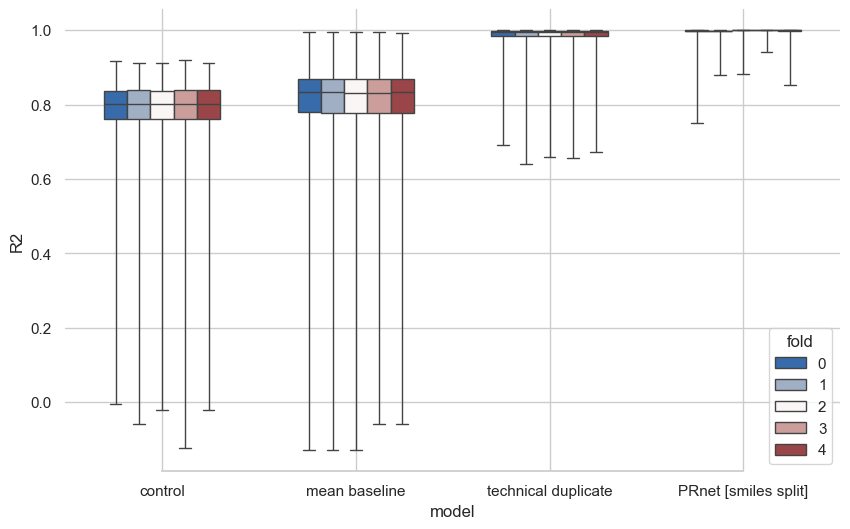

In [37]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    metrics_df, x="model", y="Pearson", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="R2")
sns.despine(trim=True, left=True)

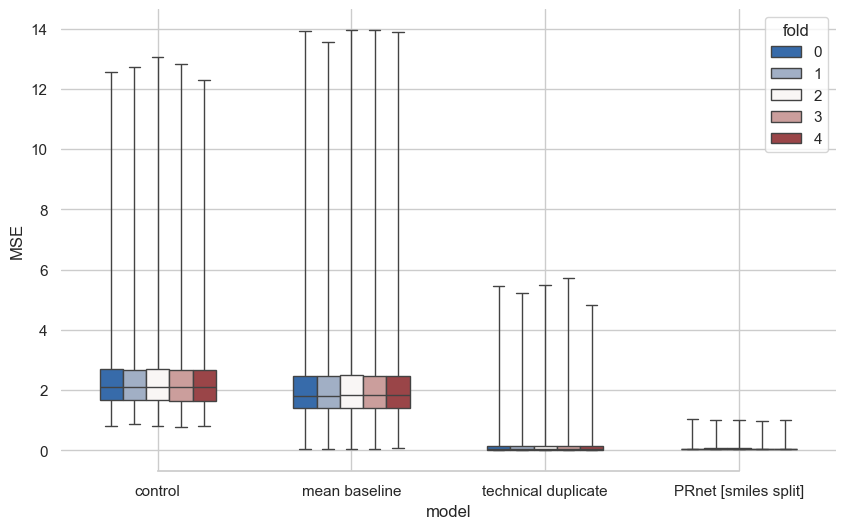

In [38]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    metrics_df, x="model", y="MSE", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="MSE")
sns.despine(trim=True, left=True)

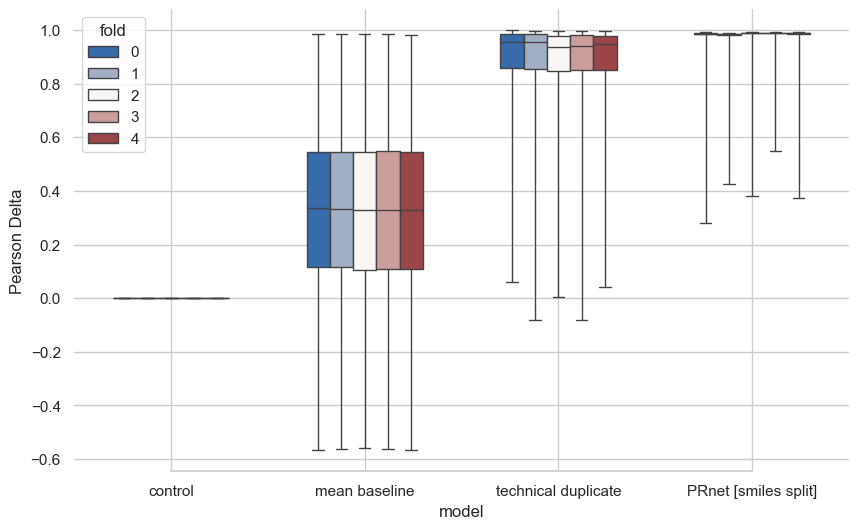

In [39]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    metrics_df, x="model", y="Pearson Delta", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta")
sns.despine(trim=True, left=True)

ValueError: Could not interpret value `r2` for `y`. An entry with this name does not appear in `data`.

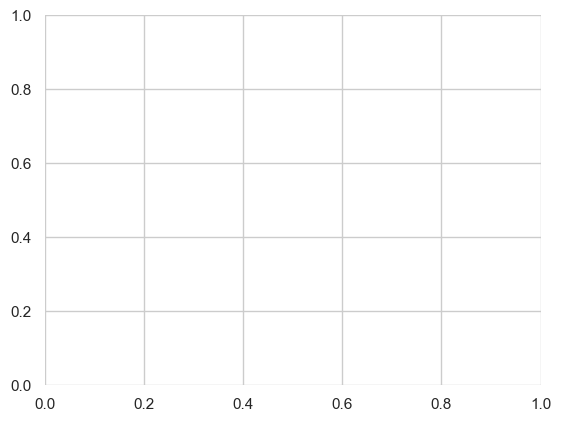

In [31]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=data_split_strats, x="prnet_training", y="r2", hue="fold",
    dodge=True, alpha=.25, zorder=1, legend=True,
)

sns.pointplot(
    data=data_split_strats, x="prnet_training", y="r2", hue="fold",
    dodge=0.65, palette='dark:black', errorbar=("sd"), legend=False,
    markers="d", markersize=2, linestyle="none", err_kws={'linewidth': 1},
)


<Axes: xlabel='prnet_training', ylabel='mse'>

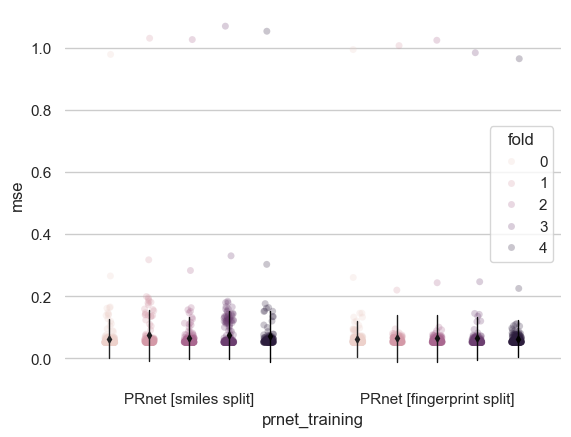

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=data_split_strats, x="prnet_training", y="mse", hue="fold",
    dodge=True, alpha=.25, zorder=1, legend=True,
)

sns.pointplot(
    data=data_split_strats, x="prnet_training", y="mse", hue="fold",
    dodge=0.65, palette='dark:black', errorbar=("sd"), legend=False,
    markers="d", markersize=2, linestyle="none", err_kws={'linewidth': 1},
)